In [1]:
from IPython.display import display, HTML

display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:13pt;}
div.prompt {min-width:80px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:2px;}
table.dataframe{font-size:2xpt;}
div.text_cell_render h1 {
    color: #001A99 !important;
    font-weight: bold;
}
div.text_cell_render hr {
    border: 0 !important;
    height: 2px !important;
    background-color: #4FC3F7 !important;
}
</style>
"""))

# 1절. 변수 선택과 차원축소
## 1-1 변수선택과 차원축소
- 종속변수에영향을주는변수들을찾아학습에사용할독립변수의수를줄임(어떻게하면score를 높일수있을지?)
- 과적합과변수들사이의다중공선성(변수들간강한상관관계)을줄일수있음
* 회귀계수 해석이어려워짐. 모델예측력이좋아도해석력이떨어짐(어떤변수가제일큰요인인지잘), p값이나유의성검정이왜곡될수있음- 모형의학습시간을줄일수있음
- 주성분분석, 상관분석, **분류모형의 feature_importance_, 예측 모형의 coef_**
- SelectKBest : 가장 높은 score에 따라 K개의 특징을 선택
## 1-2 주성분분석(PCA, Principal Component Anaysis)
- 주성분분석은변수선택및차원축소방법(기존의모든변수를조합하여새로운변수로만듦) 으로널리사용
- 주성분분석은상관관계가있는변수들을선형결합해서**분산이극대화된상관관계가없는새로운변수(주성분)들로축약**하는것
- 주성분분석은사실선형대수학이라기보다는선형대수학의활용적인측면이강하며영상인식, 통계데이터분석(주성분 찾기), 데이터 압축, 노이즈제거 등여러분야에사용
- 영상처리에서많이활용: 여러개의영상중대표이미지를찾을때활용

In [2]:
import seaborn as sns
from sklearn.decomposition import PCA
iris = sns.load_dataset('iris')
iris_X, iris_y = iris.iloc[:, :-1], iris.iloc[:, -1]
iris_X.shape, iris_y.shape

((150, 4), (150,))

In [3]:
# 다중공전성이 있는 독립변수 4개를 다중공전성전혀 없는 새로운 독립변수 2개로
pca = PCA(n_components=2) # n_components : 주성분 갯수
pca.fit(iris_X)
iris_pca = pca.transform(iris_X)
iris_pca[:3] # 주성분 2개

array([[-2.68412563,  0.31939725],
       [-2.71414169, -0.17700123],
       [-2.88899057, -0.14494943]])

In [4]:
import pandas as pd
df = pd.DataFrame(iris_pca, columns=['pca1', 'pca2'])
df.corr()

,pca1,pca2
pca1,1.000000e+00,1.407550e-15
pca2,1.407550e-15,1.000000e+00


In [5]:
# iris_X => df
pd.concat([iris_X, df], axis=1)

,sepal_length,sepal_width,petal_length,petal_width,pca1,pca2
0,5.1,3.5,1.4,0.2,-2.684126,0.319397
1,4.9,3.0,1.4,0.2,-2.714142,-0.177001
2,4.7,3.2,1.3,0.2,-2.888991,-0.144949
3,4.6,3.1,1.5,0.2,-2.745343,-0.318299
4,5.0,3.6,1.4,0.2,-2.728717,0.326755
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,1.944110,0.187532
146,6.3,2.5,5.0,1.9,1.527167,-0.375317
147,6.5,3.0,5.2,2.0,1.764346,0.078859
148,6.2,3.4,5.4,2.3,1.900942,0.116628


In [6]:
# 설명분산 : 각 주성분이 원 데이터정보량을 얼마나 잘 표현하는지 : 값이 클수록 더 중요한 주성분
pca.explained_variance_

array([4.22824171, 0.24267075])

In [7]:
pca.explained_variance_ratio_ 
# 0~1사이의 비율로 조정된 설명분산
# 2개의 주성분으로 전체 데이터(독립변수4)의 97.77% 정도 설명

array([0.92461872, 0.05306648])

In [8]:
pca.components_ # 주성분의 계수 : 각 주성분이 원래 특성들과 어떤 관계가 있는지의 가중치
# pca1 = 0.36138659*x0 -0.08452251*x1 + 0.85667061*x2 + 0.3582892*x3
# pca2 = 0.65658877*x0 + 0.73016143*x1 - 0.17337266*x2 - 0.07548102*x3

array([[ 0.36138659, -0.08452251,  0.85667061,  0.3582892 ],
       [ 0.65658877,  0.73016143, -0.17337266, -0.07548102]])

## 1.3 상관관계 확인
- 타겟변수와 상관관계가 높은 독립변수들만 선택

In [9]:
# redwine = pd.read_csv('data/winequality-red.csv', sep=';')
redwine = pd.read_csv('data/winequality-red.csv', delimiter=';')
redwine.sample()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
837,6.7,0.28,0.28,2.4,0.012,36.0,100.0,0.99064,3.26,0.39,11.7,7


- cmap의 종류 : https://jrc-park.tistory.com/155
- http://seaborn.pydata.org/generated/seaborn.heatmap.html#seaborn.heatmap
- http://seaborn.pydata.org/examples/many_pairwise_correlations.html

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['figure.figsize'] = (20, 4)

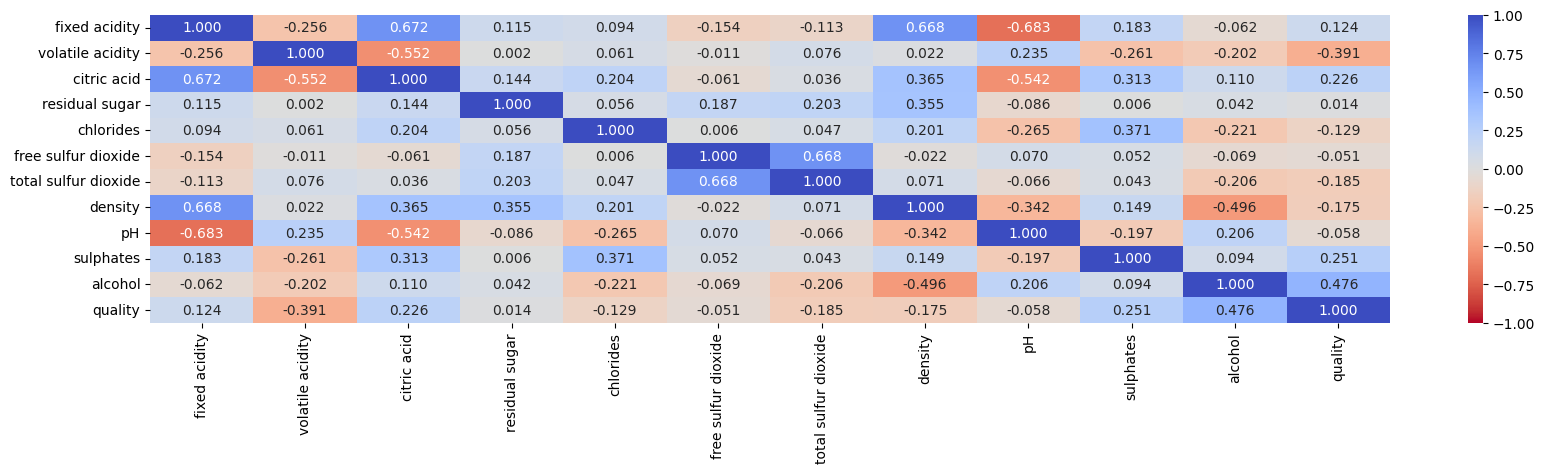

In [11]:
corr = redwine.corr()
#corr
sns.heatmap(corr, annot=True, fmt='.3f', vmin=-1, vmax=1, cmap='coolwarm_r')
plt.show()

In [12]:
mask = np.tril(np.ones_like(corr), k=0) # 대각선 포함 아래가 1인 삼각행렬(기본값0)
mask = np.tril(np.ones_like(corr), k=-1) # 대각선 제외 아래가 1인 삼각행렬
mask = np.triu(np.ones_like(corr), k=1)  # 대각선 제외 위가 1인 삼각행렬
mask = np.triu(np.ones_like(corr), k=0)  # 대각선 포함 위가 1인 삼각행렬
mask

array([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])

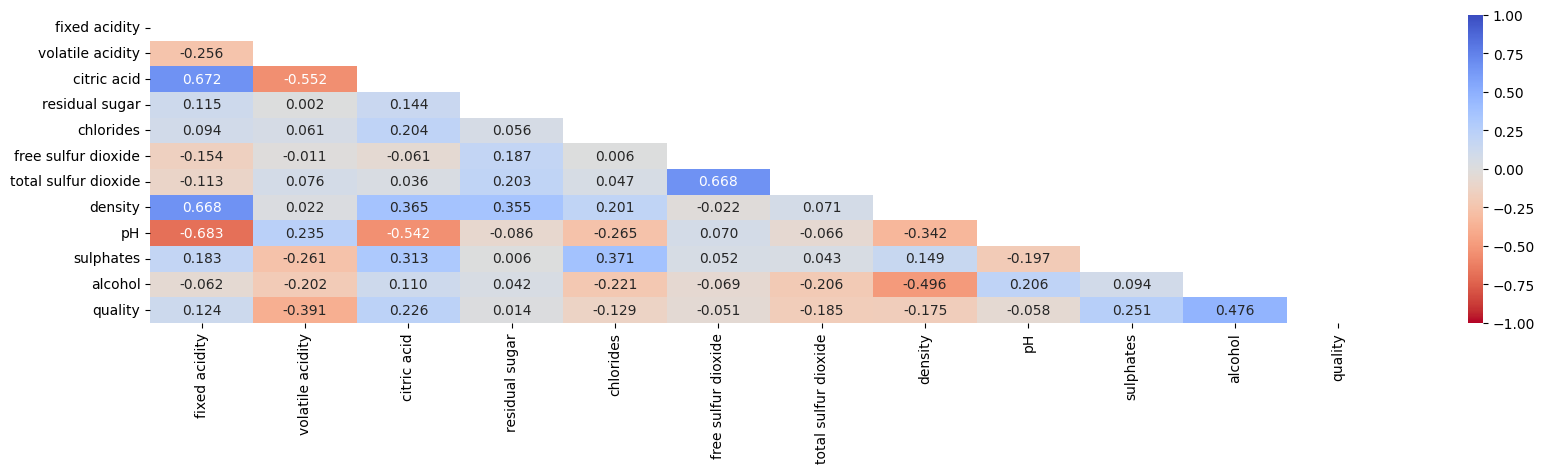

In [13]:
sns.heatmap(corr, annot=True, fmt='.3f', vmin=-1, vmax=1, cmap='coolwarm_r', mask=mask)
plt.show()

## 1.4 분류모형의 feature_importance_
- 모형의 feature_importance_ 속성은 독립변수들이 종속변수에 영향을 주는 정도를 저장
- DecisionTreeClassifier, RandomForestClassifier(tree계열), GradientBoostingClassifier, XGBclassifier, LGBMclassifier, CatBoostClassifier
- LogisticRegression이나 SVC, MLPclassifier, MultinomialNB등은 feature_importance_없음

In [14]:
X = redwine.iloc[:, :-1].to_numpy()
y = redwine.iloc[:, -1].values
from sklearn.model_selection import train_test_split
train_X, test_X, train_y, test_y = train_test_split(X, y,
                                                   test_size=0.3,
                                                   stratify=y) # 층화추출
train_X.shape, train_y.shape, test_X.shape, test_y.shape, type(train_X)

((1119, 11), (1119,), (480, 11), (480,), numpy.ndarray)

In [15]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=10,
                                 random_state=10)
rf_model.fit(train_X, train_y)

RandomForestClassifier(n_estimators=10, random_state=10)

In [16]:
features = pd.DataFrame(np.c_[redwine.columns[:-1],
                            rf_model.feature_importances_],
                       columns=['feature', 'importance'])
features['importance'].sum()

1.0000000000000002

In [17]:
features.sort_values(by='importance', ascending=False, inplace=True)
features

,feature,importance
10,alcohol,0.145511
9,sulphates,0.113087
6,total sulfur dioxide,0.100658
7,density,0.098608
4,chlorides,0.09471
1,volatile acidity,0.085914
8,pH,0.085181
2,citric acid,0.08075
0,fixed acidity,0.06826
3,residual sugar,0.063761


### feature_importance_를 이용한 변수 중요도 시각화

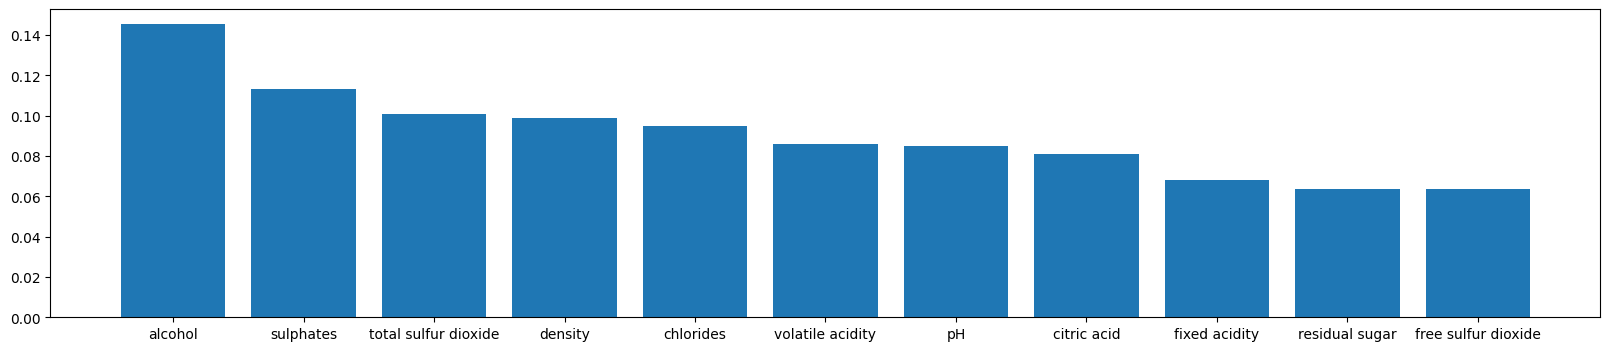

In [18]:
plt.bar(features.feature, features.importance)
plt.show()

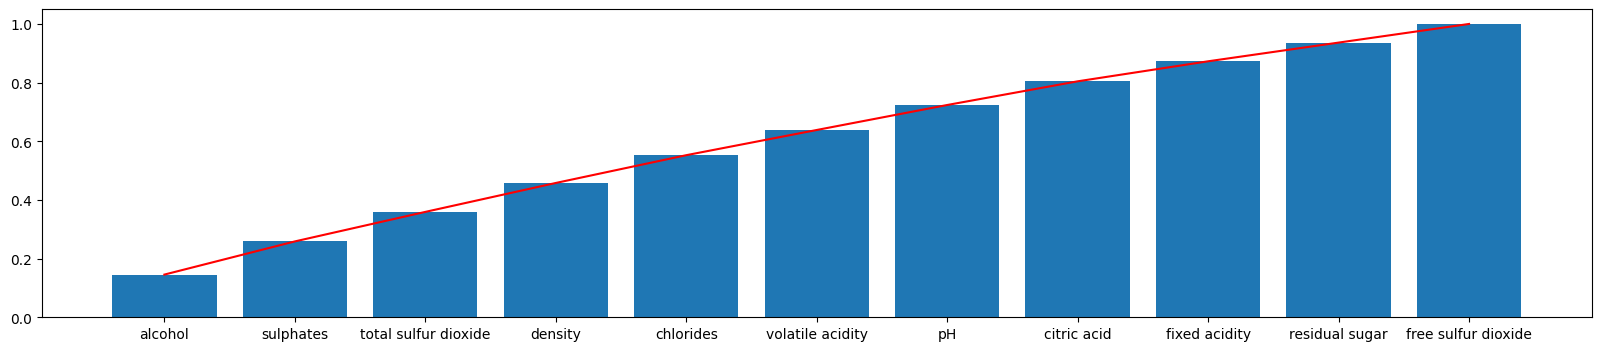

In [19]:
# 누적합을 이용한 시각화
y_stack = np.cumsum(features.importance) # importance 누적
# y_stack 
plt.bar(features.feature, y_stack)
plt.plot(features.feature, y_stack, c='r')
plt.show()

### RFE(Recursive Feature Elimination) 방식
- 중요도에 따라 낮은 변수부터 하나씩 제거해 나가면서 최종적으로 선택하고자 하는 변수의 갯수만큼 남긴다

In [25]:
# 5개의 특징이 남을 때까지 변수를 제거(기준 : feature_importance_)
from sklearn.feature_selection import RFE
rfe_model = RFE(#RandomForestClassifier(n_estimators=10,random_state=10)
    rf_model,
    n_features_to_select=5
)
rfe_model.fit(train_X, train_y)
# rfe_model.get_support()
features_rfe = pd.DataFrame(np.c_[redwine.columns[:-1],
                                 rfe_model.get_support()],
                           columns=['feature', 'selected'])
features_rfe.sort_values(by='selected', ascending=False)

,feature,selected
1,volatile acidity,True
6,total sulfur dioxide,True
7,density,True
9,sulphates,True
10,alcohol,True
0,fixed acidity,False
2,citric acid,False
3,residual sugar,False
4,chlorides,False
5,free sulfur dioxide,False


## 1.5 SelectKBest
- 가장 높은 score 따라 k개의 특징 변수 선택

In [26]:
from sklearn.datasets import load_iris
X, y = load_iris(return_X_y=True)
X.shape, y.shape, type(X)

((150, 4), (150,), numpy.ndarray)

In [27]:
from sklearn.feature_selection import SelectKBest, f_classif
X_new = SelectKBest(score_func=f_classif, # 기본값
                   k=2).fit_transform(X, y) # score가 높은 독립변수 2개 추출
X_new[:3]

array([[1.4, 0.2],
       [1.4, 0.2],
       [1.3, 0.2]])

# 2절. 파라미터 탐색
- 하이퍼파라미터(사용자가 직접 설정할 수 있는 파라미터). 어떤 파라미터를 넣는게 최적의 결과를 낼지 탐색

    * validation_curve() : 단일 하이퍼파라미터 최적화 함수(한개의 파라미터 찾아줌)
    * GridSearchCV : 그리드를 이용한 복수 하이퍼 파라미터 최적화 클래스(가장 높은 score를 내는 모형를 찾아줌)

## 2-1 단일 파라미터 탐색과 모형 최적화
- validation_curve() : 최적화할 파라미터 이름과 범위, 성능 측정 기준을 매개변수로 받아, 파라미터의 모든 범위의 성능을 계산

In [28]:
# 데이터
from sklearn.datasets import load_digits
digits = load_digits()
X, y = digits.data, digits.target
images = digits.images
X.shape, y.shape, images.shape

((1797, 64), (1797,), (1797, 8, 8))

In [29]:
import numpy as np
np.all(X[0].reshape(8,8) == images[0]) # 행렬의 모든 item에 True인지 여부

True

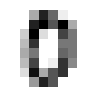

In [30]:
import matplotlib.pyplot as plt
plt.figure(figsize=(1,1))
plt.imshow(images[0], cmap='gray_r')
plt.axis('off')
plt.show()

In [31]:
# SVC 모델 생성
from sklearn.svm import SVC
model = SVC(probability=True)
model.fit(X, y)

SVC(probability=True)

In [32]:
model.score(X, y)

0.996661101836394

In [33]:
h = model.predict(X[0].reshape(1, -1))[0]
prob = model.predict_proba(X[0].reshape(1, -1))[0]
model.classes_

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [34]:
print(f'예측 : {h}')
for c, p in zip(model.classes_, prob):
    print(f'{c}일 확률 : {p:.2%}')

예측 : 0
0일 확률 : 99.11%
1일 확률 : 0.02%
2일 확률 : 0.05%
3일 확률 : 0.09%
4일 확률 : 0.06%
5일 확률 : 0.14%
6일 확률 : 0.07%
7일 확률 : 0.10%
8일 확률 : 0.07%
9일 확률 : 0.29%


In [35]:
print(model.get_params())

{'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': True, 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}


In [36]:
# 탐색할 gamma의 범위
param_range = np.linspace(0.000001, 0.1, 10)
param_range = np.logspace(-6, -1, 10)
param_range

array([1.00000000e-06, 3.59381366e-06, 1.29154967e-05, 4.64158883e-05,
       1.66810054e-04, 5.99484250e-04, 2.15443469e-03, 7.74263683e-03,
       2.78255940e-02, 1.00000000e-01])

In [37]:
%%time
from sklearn.svm import SVC
from sklearn.model_selection import validation_curve
train_score, test_score = validation_curve(
                        SVC(), # 예측모형
                        X, y, # 데이터
                        param_name='gamma', # gamma가 크면 결정경계 복잡
                        param_range=param_range,
                        cv=10, # 교차검증 10개로 나눠 1개는 test셋, 9개는 train
                        scoring='accuracy', # 모형평가 기준(precision, recall, f1, roc_auc, ...)
                        n_jobs=-1   # 사용할 core 갯수(-1은 모든 core를 다 씀)
                      )

CPU times: total: 859 ms
Wall time: 13.5 s


In [38]:
test_score.shape, train_score.shape

((10, 10), (10, 10))

In [39]:
# 행별 평균
train_scores_mean = np.mean(train_score, axis=1)
train_scores_std  = np.std(train_score, axis=1)
test_scores_mean = np.mean(test_score, axis=1)
test_scores_std  = np.std(test_score, axis=1)

In [40]:
test_scores_std

array([0.06458693, 0.02805082, 0.03841992, 0.03207261, 0.02606765,
       0.02054497, 0.01863724, 0.05734476, 0.0509597 , 0.00764792])

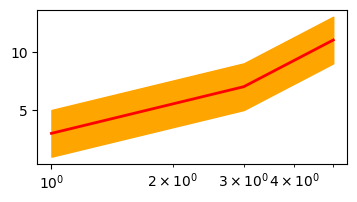

In [41]:
plt.figure(figsize=(4,2))
a = np.array([1, 3, 5])
b = np.array([3, 7, 11])
plt.semilogx(a, b, c='r', lw=2)
plt.fill_between(a, b-2, b+2, color='orange')
plt.show()

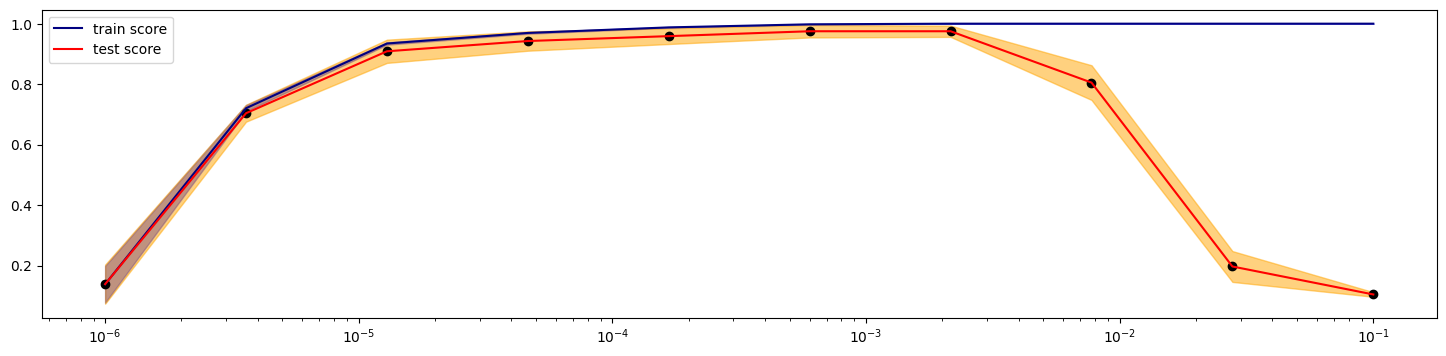

In [42]:
plt.figure(figsize=(18,4))
plt.semilogx(param_range, train_scores_mean, label='train score', color='navy')
plt.fill_between(param_range,
                train_scores_mean-train_scores_std,
                train_scores_mean+train_scores_std,
                color='blue', alpha=0.5)
plt.semilogx(param_range, test_scores_mean, label='test score', color='red')
plt.fill_between(param_range,
                test_scores_mean-test_scores_std,
                test_scores_mean+test_scores_std,
                color='orange', alpha=0.5)
plt.scatter(param_range, test_scores_mean, c='k')
plt.legend(loc='best')
plt.show()

In [43]:
test_scores_mean.argmax() # 최적의 gamma값이 있는 index

6

In [44]:
gamma = param_range[test_scores_mean.argmax()]
gamma

0.0021544346900318843

In [45]:
model = SVC(gamma=gamma).fit(X, y)
model.score(X, y)

1.0

## 2-2 GridSearchCV
- 복수 하이퍼 파라미터 최적화 클래스
- 모형 래퍼 성격 클래스(가장 좋은 모형을 가지고 있음)
- fit(), predict(), score(), predict_proba(), decition_function() 메소드 가능

In [46]:
import pandas as pd
redwine = pd.read_csv('data/winequality-red.csv', sep=';')
redwine_X, redwine_y = redwine.iloc[:, :-1], redwine.iloc[:, -1]
redwine_X.shape, redwine_y.shape

((1599, 11), (1599,))

In [47]:
%%time
from sklearn.feature_selection import SelectKBest
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
selection = SelectKBest(k=1) # 가장 Anova f검정의 score가 높은 k개 변수를 찾음
svc       = SVC()
pipeline = Pipeline([('select', selection),
                     ('svc',    svc)])
# param_grid = {'select__k':[4,5,6,7,8,9,10,11],
#               'svc__C':[0.1, 1, 10], # 값이 클수록 오차허용이 엄격
#               'svc__gamma':[0.001, 0.002]
#              }
param_grid = dict(select__k=[4,5,6,7,8,9,10,11],
                  svc__C = [0.1, 1, 10],
                  svc__gamma = [0.001, 0.002])
grid_search = GridSearchCV(pipeline,
                          param_grid=param_grid, # 파라미터들
                          cv=2, # 2fold 교차검증
                          verbose=1,
                          n_jobs=-1 # 모든 코어를 다 씀 
                          )
grid_search.fit(redwine_X, redwine_y)

Fitting 2 folds for each of 48 candidates, totalling 96 fits
CPU times: total: 844 ms
Wall time: 9.19 s


GridSearchCV(cv=2,
             estimator=Pipeline(steps=[('select', SelectKBest(k=1)),
                                       ('svc', SVC())]),
             n_jobs=-1,
             param_grid={'select__k': [4, 5, 6, 7, 8, 9, 10, 11],
                         'svc__C': [0.1, 1, 10], 'svc__gamma': [0.001, 0.002]},
             verbose=1)

In [48]:
# 최적의 파라미터값과 selectKBest의 k값
print(grid_search.best_estimator_)

Pipeline(steps=[('select', SelectKBest(k=11)), ('svc', SVC(C=10, gamma=0.002))])


In [49]:
# 최적의 파라미터값과 selectKBest의 k값
print(grid_search.best_params_)

{'select__k': 11, 'svc__C': 10, 'svc__gamma': 0.002}


In [50]:
model = grid_search.best_estimator_
model.score(redwine_X, redwine_y)

0.6035021888680425

In [51]:
# 학습데이터가 넘파이면 predict도 넘파이로, 학습데이터 데이터프레임이면 predict도 데이터프레임으로(경고출력X)
# x_data = redwine_X.iloc[0].values.reshape(1, -1)
x_data = pd.DataFrame(redwine_X.iloc[0]).T 
model.predict(x_data)

array([5], dtype=int64)

# 3절. 자료 불균형 처리
- 단순 언더/오버 샘플링
- 단순 오버 샘플링시 소수의 데이터를 단순 복사하면, 그 데이터에 의해 과적합 발생 가능
- SMOTE 오버 샘플링

## 3-1 SMOTE를 이용한 오버샘플링 전

In [53]:
# 데이터
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=10000, # 표본 데이터수
                           n_features=10,   # 독립변수 수
                           n_informative=5, # 종속변수와 상관관계가 있는 독립변수 수
                           n_classes=2,     # 종속변수의 클래스 수
                           n_clusters_per_class=1, # 클래스당 군의 수
                           weights=[0.99,0.01], # 각 클래스의 할당된 표본 비율
                           random_state=42
                          )
X.shape, y.shape

((10000, 10), (10000,))

In [54]:
import numpy as np
np.unique(y, return_counts=True)

(array([0, 1]), array([9850,  150], dtype=int64))

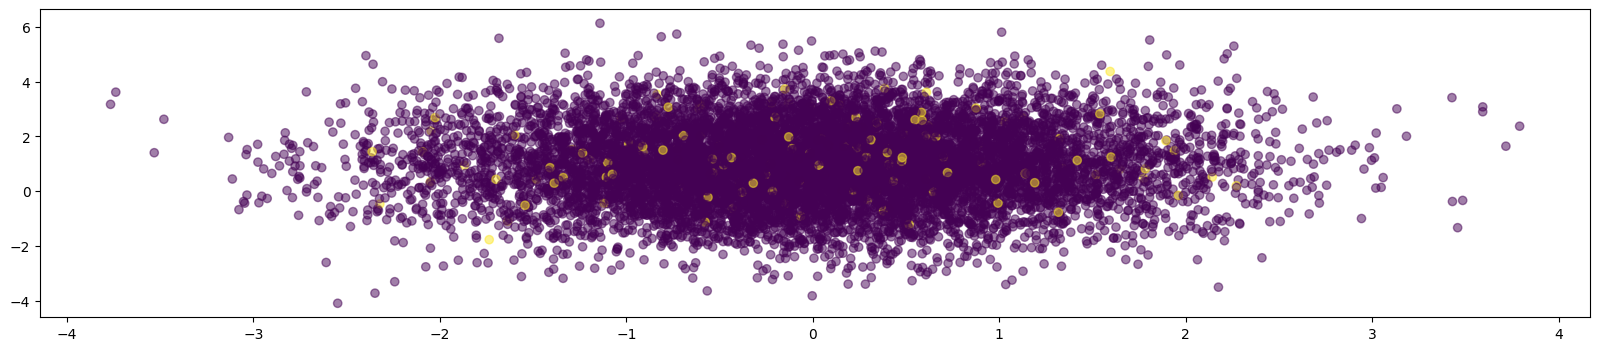

In [55]:
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0], y=X[:, 1], c=y, alpha=0.5)

In [56]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                   test_size=0.3,
                                                   stratify=y, # 층화추출
                                                   random_state=42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((7000, 10), (7000,), (3000, 10), (3000,))

In [57]:
print(np.unique(y, return_counts=True))
print(np.unique(y_train, return_counts=True))
print(np.unique(y_test, return_counts=True))

(array([0, 1]), array([9850,  150], dtype=int64))
(array([0, 1]), array([6895,  105], dtype=int64))
(array([0, 1]), array([2955,   45], dtype=int64))


In [58]:
y.mean(), y_train.mean(), y_test.mean()

(0.015, 0.015, 0.015)

In [59]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, # 모델에서 사용할 트리 갯수
                                 max_features=2, # 각 노드에서 분할에 사용할 특징(열)의 최대수
                                 random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_features=2, random_state=42)

In [60]:
rf_pred = rf_model.predict(X_test)
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, rf_pred)

array([[2955,    0],
       [  35,   10]], dtype=int64)

In [61]:
from sklearn.metrics import classification_report
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2955
           1       1.00      0.22      0.36        45

    accuracy                           0.99      3000
   macro avg       0.99      0.61      0.68      3000
weighted avg       0.99      0.99      0.98      3000



## 3.2 SMOTE를 이용한 오버샘플링 후
- pip install imbalanced-learn=0.10.1

In [62]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((7000, 10), (7000,), (3000, 10), (3000,))

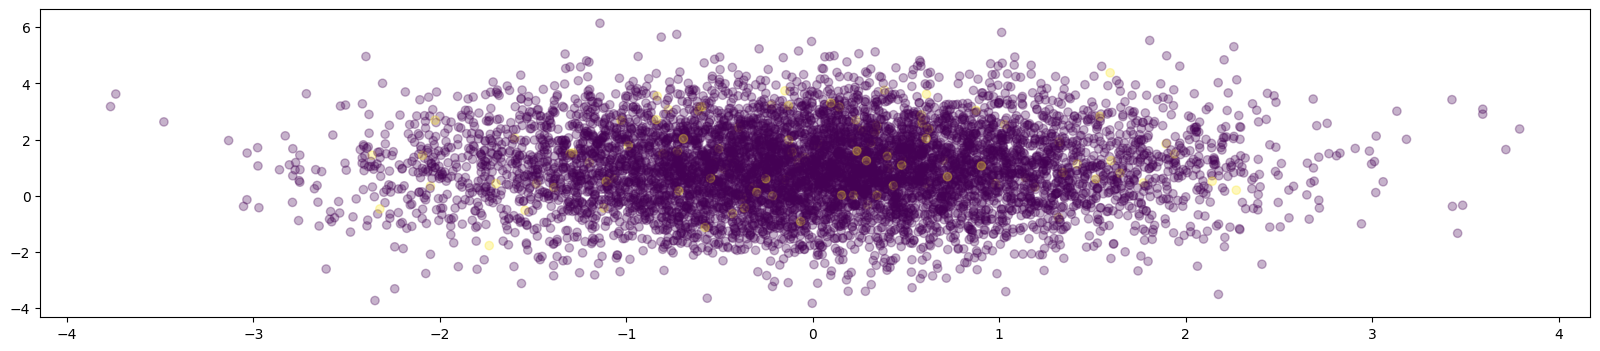

In [63]:
plt.scatter(x=X_train[:, 0], y=X_train[:,1], c=y_train, alpha=0.3)
plt.show()

In [64]:
np.unique(y_train, return_counts=True), y_train.shape

((array([0, 1]), array([6895,  105], dtype=int64)), (7000,))

In [65]:
# SMOTE 오버샘플링(X_train에만 적용)
from imblearn.over_sampling import SMOTE
sm = SMOTE(
        # sampling_strategy={0:6895, 1:1050}
)
X_resampled, y_resampled = sm.fit_resample(X_train, y_train)
X_resampled.shape, y_resampled.shape

((13790, 10), (13790,))

In [66]:
np.unique(y_resampled, return_counts=True)

(array([0, 1]), array([6895, 6895], dtype=int64))

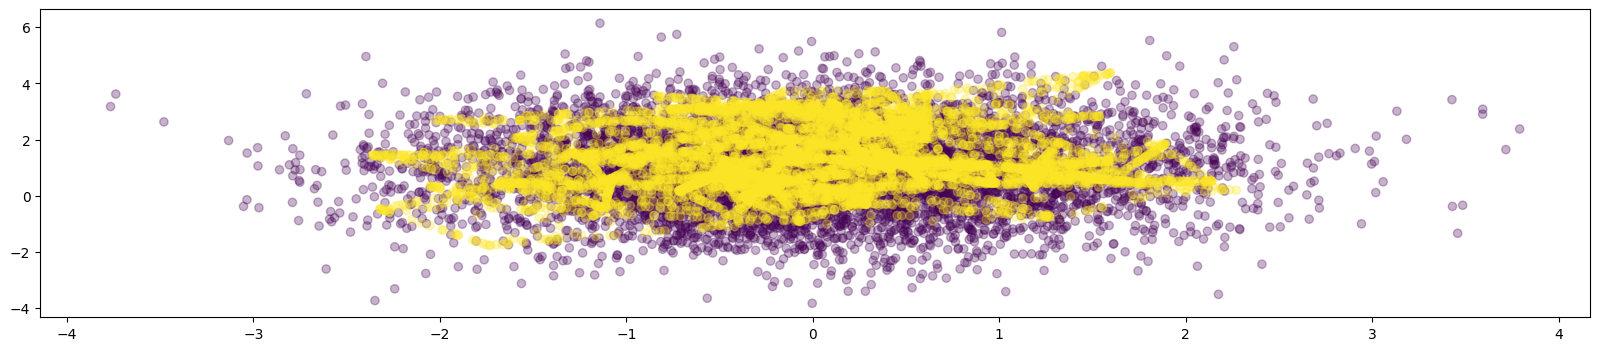

In [67]:
plt.scatter(x=X_resampled[:, 0], y=X_resampled[:,1], c=y_resampled, alpha=0.3)
plt.show()

In [68]:
rf_model = RandomForestClassifier(n_estimators=100,
                                 max_features=2,
                                 random_state=42)
rf_model.fit(X_resampled, y_resampled)

RandomForestClassifier(max_features=2, random_state=42)

In [73]:
rf_pred = rf_model.predict(X_test)
confusion_matrix(y_test, rf_pred)

array([[2955,    0],
       [  35,   10]], dtype=int64)

In [74]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2955
           1       1.00      0.22      0.36        45

    accuracy                           0.99      3000
   macro avg       0.99      0.61      0.68      3000
weighted avg       0.99      0.99      0.98      3000



## 3.3 가중치 제어
- 예측 모형에 class_weight 매개변수 이용

In [69]:
rf_model = RandomForestClassifier(n_estimators=100, max_features=2,
                                  class_weight={0:1, 1:2.5}, # y가 1인 데이터 2.5배 더 중요하게
                                  random_state=42
                                 )
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight={0: 1, 1: 2.5}, max_features=2,
                       random_state=42)

In [70]:
rf_pred = rf_model.predict(X_test)
confusion_matrix(y_test, rf_pred)

array([[2955,    0],
       [  35,   10]], dtype=int64)

In [71]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2955
           1       1.00      0.22      0.36        45

    accuracy                           0.99      3000
   macro avg       0.99      0.61      0.68      3000
weighted avg       0.99      0.99      0.98      3000



# 4절. 최적 모형 탐색
- 앙상블 모형
    * 목적 : 여러 분류모델을 하나의 통합분류모델로 연결하여 개별 분류모델보다 더 좋은 일반화 성능을 달성
    * 방법
        + 여러 분류 알고리즘 사용 : 다수결 투표(Votiong)
        + 하나의 분류 알고리즘을 여러 개 사용 : 배깅(bagging; 데이터 복원추출하여 병렬), 부스팅(boosting; 자료불균형일 경우 조금 더 잘 맞는 경향)

## cf. 배깅 알고리즘 시

In [76]:
np.random.choice(10,10, replace=True) #10개 데이터에서 복원 추출로 10개로 뽑음

array([4, 6, 2, 2, 8, 0, 3, 8, 8, 4])

In [84]:
N = 10000000 # 63.2% → 부트스트래핑과 0.632 규칙
bootstrap = np.random.choice(N, N, replace=True)
print(len(set(bootstrap)), '개')
print(len(set(bootstrap))/N *100, '%')

6321729 개
63.217290000000006 %


## 4.1 배깅
- RandomForest

In [85]:
import pandas as pd
wine_df = pd.read_csv('data/wine.csv')
wine_df.head()

,Class label,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,0D280/0D315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [86]:
wine_df['Class label'].value_counts()

2    71
1    59
3    48
Name: Class label, dtype: int64

In [89]:
X = wine_df.iloc[:, 1:]
y = wine_df.iloc[:, 0]
X.shape, y.shape

((178, 13), (178,))

In [96]:
from sklearn.model_selection import train_test_split
train_X, test_X, train_y, test_y = train_test_split(X, y,
                                                    test_size=0.3,
                                                    stratify=y,
                                                    random_state=1
                                                   )
train_X.shape, test_X.shape

((124, 13), (54, 13))

In [95]:
# 의사결정나무 알고리즘
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(criterion='entropy', random_state=1)
tree.fit(train_X, train_y)
tree.score(test_X, test_y)

0.9074074074074074

In [98]:
%%time
# 배깅 알고리즘
from sklearn.ensemble import BaggingClassifier
bag = BaggingClassifier(estimator=tree,
                        n_estimators=500,
                        bootstrap=True, # 복원 추출 중복 추출 허용
                        oob_score=True, # 중복 추축로 학습에 빠진 데이터를 score에 적용한 점수를 볼 수 있음.
                        random_state=1
                       )
bag.fit(train_X, train_y)
bag.score(test_X, test_y)

CPU times: total: 2.5 s
Wall time: 2.89 s


0.9629629629629629

In [99]:
# 각 모델이 학습할 때 뽑히지 않은 샘플을 이용하여 계산하여 성능 점수
bag.oob_score_

0.9435483870967742

In [101]:
tf = RandomForestClassifier().fit(train_X, train_y)
tf.score(test_X, test_y)

1.0

## 4.2 임의의 데이터를 만들어 최적 모형 탐색

In [102]:
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=1000,
                           n_features=10,
                           n_informative=5,
                           n_classes=2,
                           n_clusters_per_class=1,
                           weights=[0.9, 0.1],
                           random_state=42
                          )
X.shape, y.shape, np.unique(y, return_counts=True)

((1000, 10), (1000,), (array([0, 1]), array([896, 104], dtype=int64)))

In [104]:
train_X, test_X, train_y, test_y = train_test_split(X, y,
                                                    test_size=0.2,
                                                    stratify=y,
                                                    random_state=42
                                                   )
# train데이터의 오버샘플링
sm = SMOTE()
resampled_X, resampled_y = sm.fit_resample(train_X, train_y)
resampled_X.shape, resampled_y.shape, np.unique(resampled_y, return_counts=True)

((1434, 10), (1434,), (array([0, 1]), array([717, 717], dtype=int64)))

In [105]:
from sklearn.metrics import precision_score, recall_score, f1_score
def model_measure(model, train_X=resampled_X, train_y=resampled_y, test_X=test_X, test_y=test_y):
    '매개변수로 받은 모델을 학습한 후, 모델의 정확도, 정밀도, 재현율, f1점수를 return'
    model.fit(train_X, train_y) # 학습
    pred = model.predict(test_X) # 예측값
    accuracy = model.score(test_X, test_y)
    precision = precision_score(test_y, pred)
    recall = recall_score(test_y, pred)
    f1score = f1_score(test_y, pred)
    return '정확도:{:.3f}, 정밀도:{:.3f}, 재현율:{:.3f}, f1 score:{:.3f},'.format(accuracy,
                                                                               precision,
                                                                               recall,
                                                                               f1score)

In [106]:
model_measure(RandomForestClassifier(n_estimators=100, max_features=2, random_state=42))

'정확도:0.985, 정밀도:0.909, 재현율:0.952, f1 score:0.930,'

In [107]:
rf_model = RandomForestClassifier(n_estimators=100, max_features=2, random_state=42)
model_measure(rf_model)

'정확도:0.985, 정밀도:0.909, 재현율:0.952, f1 score:0.930,'

In [108]:
from sklearn.svm import SVC
svc_model = SVC(random_state=42)
model_measure(svc_model)

'정확도:0.990, 정밀도:1.000, 재현율:0.905, f1 score:0.950,'

In [119]:
from lightgbm import LGBMClassifier
# 행 기준으로 각 피처를 빠르게 탐색
model_measure(LGBMClassifier(n_estimators=100, verbose=0))

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


'정확도:0.985, 정밀도:0.909, 재현율:0.952, f1 score:0.930,'

In [120]:
from sklearn.neural_network import MLPClassifier
mlp_model = MLPClassifier(hidden_layer_sizes=42)
model_measure(svc_model)

'정확도:0.990, 정밀도:1.000, 재현율:0.905, f1 score:0.950,'

## 4.3 부스팅(AdaBoost, XGB, LGBM, CatB)
- 알고리즘들을 순차적으로 학습하면서 이전 학습한 알고리즘 예측이 틀린 데이터를 올바르게 예측할 수 있도록 가중치 부여

In [121]:
from sklearn.ensemble import AdaBoostClassifier
model_measure(AdaBoostClassifier())

'정확도:0.970, 정밀도:0.826, 재현율:0.905, f1 score:0.864,'

In [122]:
from xgboost import XGBClassifier
model_measure(XGBClassifier(n_estimators=100, max_depth=10, learning_rate=0.01))

'정확도:0.955, 정밀도:0.714, 재현율:0.952, f1 score:0.816,'

## 4. 4 투표를 이용한 앙상블
- voting = "hard":다수결로 투표
- voting='sorft' : 확률의 합을 계산하여 투표

In [123]:
rf_model = RandomForestClassifier(n_estimators=100, max_features=2, random_state=42)
xgb_model = XGBClassifier(max_depth=10,
                         n_estimators=100) # 이진분류에서의 평가 지표
lgb_model = LGBMClassifier(n_estimators=100, verbose=0)
svc_model = SVC(probability=True, random_state=42)
print(model_measure(rf_model))
print(model_measure(xgb_model))
print(model_measure(lgb_model))
print(model_measure(svc_model))

정확도:0.985, 정밀도:0.909, 재현율:0.952, f1 score:0.930,
정확도:0.980, 정밀도:0.870, 재현율:0.952, f1 score:0.909,
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
정확도:0.985, 정밀도:0.909, 재현율:0.952, f1 score:0.930,
정확도:0.990, 정밀도:1.000, 재현율:0.905, f1 score:0.950,


In [124]:
%%time
from sklearn.ensemble import VotingClassifier
voting_model = VotingClassifier(estimators=[('rfm', rf_model),
                                            ('lgb', lgb_model),
                                            ('svc', svc_model)],
                               voting='hard')
voting_model.fit(resampled_X, resampled_y)

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
CPU times: total: 3.08 s
Wall time: 2.01 s


VotingClassifier(estimators=[('rfm',
                              RandomForestClassifier(max_features=2,
                                                     random_state=42)),
                             ('lgb', LGBMClassifier(verbose=0)),
                             ('svc', SVC(probability=True, random_state=42))])

In [125]:
print(model_measure(voting_model))

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
정확도:0.990, 정밀도:0.952, 재현율:0.952, f1 score:0.952,


In [126]:
# 개별 모델
voting_model.named_estimators_

{'rfm': RandomForestClassifier(max_features=2, random_state=42),
 'lgb': LGBMClassifier(verbose=0),
 'svc': SVC(probability=True, random_state=42)}

In [127]:
from sklearn.ensemble import VotingClassifier
voting_model = VotingClassifier(estimators=[('rfm', rf_model),
                                            ('lgb', lgb_model),
                                            ('svc', svc_model)],
                               voting='soft')
model_measure(voting_model)

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


'정확도:0.990, 정밀도:0.952, 재현율:0.952, f1 score:0.952,'